In [1]:
## Har session main run karni h
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Early-Sepsis-Detection
!pip install -r requirements.txt -q


Mounted at /content/drive
/content/drive/MyDrive/Early-Sepsis-Detection


In [8]:
from google.colab import files
uploaded = files.upload()

Saving Early-Sepsis-Detection-scaffold.zip to Early-Sepsis-Detection-scaffold.zip


In [9]:
!unzip -q Early-Sepsis-Detection-scaffold.zip -d /content/Early-Sepsis-Detection
%cd /content/Early-Sepsis-Detection
!ls

/content/Early-Sepsis-Detection
app  data  models  notebooks  README.md  reports  requirements.txt  src  tests


In [12]:
!find / -name "Early-Sepsis-Detection-scaffold.zip" 2>/dev/null

/content/Early-Sepsis-Detection-scaffold.zip
/content/drive/MyDrive/ML Model Project/Early-Sepsis-Detection-scaffold.zip


In [13]:
!unzip -q "/content/drive/MyDrive/ML Model Project/Early-Sepsis-Detection-scaffold.zip" -d "/content/drive/MyDrive/Early-Sepsis-Detection"

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
%cd "/content/drive/MyDrive/Early-Sepsis-Detection"
!ls

/content/drive/MyDrive/Early-Sepsis-Detection
app  data  models  notebooks  README.md  reports  requirements.txt  src  tests


In [2]:
!ls "/content/drive/MyDrive/sepsis_data/raw/training_setA" | wc -l
!ls "/content/drive/MyDrive/sepsis_data/raw/training_setB" | wc -l

^C
20000


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/sepsis_data/raw/training_setA', exist_ok=True)
os.makedirs('/content/drive/MyDrive/sepsis_data/raw/training_setB', exist_ok=True)

In [3]:
import os
print(os.path.exists('/content/drive'))
print(os.path.exists('/content/drive/MyDrive'))

True
True


In [5]:
!ls /content/drive/MyDrive/sepsis_data

physionet.org  raw


In [6]:
%cd /content/drive/MyDrive/sepsis_data
!wget -r -N -c -np -q https://physionet.org/files/challenge-2019/1.0.0/training/

/content/drive/MyDrive/sepsis_data
^C


In [8]:
!find /content/drive/MyDrive/sepsis_data/physionet.org -name "*.psv" | wc -l

40336


In [9]:
!find /content/drive/MyDrive/sepsis_data/physionet.org -name "*.psv" -size -1k

In [2]:
!mv /content/drive/MyDrive/sepsis_data/physionet.org/files/challenge-2019/1.0.0/training/training_setA/*.psv /content/drive/MyDrive/sepsis_data/raw/training_setA/
!mv /content/drive/MyDrive/sepsis_data/physionet.org/files/challenge-2019/1.0.0/training/training_setB/*.psv /content/drive/MyDrive/sepsis_data/raw/training_setB/

/bin/bash: line 1: /usr/bin/mv: Argument list too long
/bin/bash: line 1: /usr/bin/mv: Argument list too long


In [3]:
import shutil
from pathlib import Path

src_a = Path("/content/drive/MyDrive/sepsis_data/physionet.org/files/challenge-2019/1.0.0/training/training_setA")
dst_a = Path("/content/drive/MyDrive/sepsis_data/raw/training_setA")

count = 0
for f in src_a.glob("*.psv"):
    shutil.move(str(f), str(dst_a / f.name))
    count += 1
    if count % 2000 == 0:
        print(f"Moved {count} files...")
print(f"Done: {count} files moved from setA")

Moved 2000 files...
Moved 4000 files...
Moved 6000 files...
Moved 8000 files...
Moved 10000 files...
Moved 12000 files...
Moved 14000 files...
Moved 16000 files...
Moved 18000 files...
Moved 20000 files...
Done: 20336 files moved from setA


In [4]:
src_b = Path("/content/drive/MyDrive/sepsis_data/physionet.org/files/challenge-2019/1.0.0/training/training_setB")
dst_b = Path("/content/drive/MyDrive/sepsis_data/raw/training_setB")

count = 0
for f in src_b.glob("*.psv"):
    shutil.move(str(f), str(dst_b / f.name))
    count += 1
    if count % 2000 == 0:
        print(f"Moved {count} files...")
print(f"Done: {count} files moved from setB")

Moved 2000 files...
Moved 4000 files...
Moved 6000 files...
Moved 8000 files...
Moved 10000 files...
Moved 12000 files...
Moved 14000 files...
Moved 16000 files...
Moved 18000 files...
Moved 20000 files...
Done: 20000 files moved from setB


In [10]:
!ls /content/drive/MyDrive/sepsis_data/raw/training_setA | wc -l
!ls /content/drive/MyDrive/sepsis_data/raw/training_setB | wc -l

20336
20000


In [6]:
!rm -rf /content/drive/MyDrive/sepsis_data/physionet.org

In [16]:
import os
os.environ["EARLY_SEPSIS_DATA_DIR"] = "/content/drive/MyDrive/sepsis_data/raw"

In [4]:
!sed -i '/scikit-learn-extra/d' requirements.txt

In [6]:
!pip install xgboost lightgbm catboost shap optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 18.3 MB/s eta 0:00:00


In [7]:
import numpy, pandas, sklearn, matplotlib, seaborn, tensorflow
import xgboost, lightgbm, catboost, shap, optuna
print("Sab imports OK")

Sab imports OK


# 01 — Data Understanding
### Early Sepsis Detection Using Clinical Time-Series Data
PhysioNet/CinC Challenge 2019 — https://physionet.org/content/challenge-2019/1.0.0/

**What?** Load the raw dataset patient-wise and compute an actual, unfabricated data-quality report.

**Why?** Every downstream decision (cleaning, feature engineering, splitting) depends on knowing
the true shape, missingness, and class balance of this dataset — not assumptions from the literature.

**How?** Uses `src.data_loader` to discover and read `.psv` files, then computes counts/statistics
directly from the loaded dataframe.

**Result / Decision:** Left as `[TO BE FILLED AFTER RUNNING]` — this notebook produces real numbers
only once you have downloaded the dataset into `data/raw/training_setA` and `data/raw/training_setB`.


In [8]:
import os
os.environ["EARLY_SEPSIS_DATA_DIR"] = "/content/drive/MyDrive/sepsis_data/raw"

In [20]:
import os
os.environ["EARLY_SEPSIS_DATA_DIR"] = "/content/local_data/raw"

In [21]:
import sys
from pathlib import Path

# Allow imports from project root when running notebook from notebooks/
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src import data_loader as dl

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
print("Config DATA_DIR:", config.DATA_DIR)
print("Training set A:", config.TRAINING_SET_A_DIR)
print("Training set B:", config.TRAINING_SET_B_DIR)


Config DATA_DIR: /content/drive/MyDrive/sepsis_data/raw
Training set A: /content/drive/MyDrive/sepsis_data/raw/training_setA
Training set B: /content/drive/MyDrive/sepsis_data/raw/training_setB


In [22]:
import os
import importlib

# 1. Env variable set karein (local copy ka path)
os.environ["EARLY_SEPSIS_DATA_DIR"] = "/content/local_data/raw"

# 2. config module ko reload karein taake naya path pick ho
from src import config
importlib.reload(config)

# 3. data_loader ko bhi reload karein (safety ke liye)
from src import data_loader as dl
importlib.reload(dl)

print("Config DATA_DIR:", config.DATA_DIR)
print("Training set A:", config.TRAINING_SET_A_DIR)
print("Training set B:", config.TRAINING_SET_B_DIR)

Config DATA_DIR: /content/local_data/raw
Training set A: /content/local_data/raw/training_setA
Training set B: /content/local_data/raw/training_setB


In [23]:
!ls /content/local_data/raw/training_setA | wc -l
!ls /content/local_data/raw/training_setB | wc -l

20336
20000


## 1. Discover patient files
This only lists files — it does not load any data yet, so it is safe/cheap to run first as a sanity check that paths are configured correctly.

In [24]:
try:
    files = dl.discover_patient_files()
    counts = dl.get_patient_file_counts()
    print(f"Total patient files found: {len(files)}")
    display(counts)
except FileNotFoundError as e:
    print(e)
    print()
    print(">>> STOP: place the extracted PhysioNet dataset into data/raw/training_setA "
          "and data/raw/training_setB (or set EARLY_SEPSIS_DATA_DIR) before continuing. <<<")


2026-09-13 07:50:03,622 | INFO | src.data_loader | Discovered 40336 patient files across 2 directories.
INFO:src.data_loader:Discovered 40336 patient files across 2 directories.
2026-09-13 07:50:05,790 | INFO | src.data_loader | Discovered 40336 patient files across 2 directories.
INFO:src.data_loader:Discovered 40336 patient files across 2 directories.


Total patient files found: 40336


,source_set,n_patient_files
0,A,20336
1,B,20000


## 2. Load the full dataset (patient-wise, memory-conscious)

For a first pass on a normal laptop, set `SAMPLE_N_PATIENTS = 2000` to validate the pipeline quickly,
then re-run with `SAMPLE_N_PATIENTS = None` for the real, full-dataset report.

**This sample flag is explicit and logged** — no result computed on a sample will be silently
presented as a full-dataset result; the summary section below will print whether a sample was used.


In [25]:
# Set to None for the FULL dataset. Use a small integer only for a quick pipeline smoke-test.
SAMPLE_N_PATIENTS = None  # e.g. 2000 for a fast smoke test

df = dl.load_combined_dataframe(sample_n_patients=SAMPLE_N_PATIENTS, save_parquet=(SAMPLE_N_PATIENTS is None))
print("Loaded dataframe shape:", df.shape)
print("Is this a SAMPLE (not full dataset)?:", df.attrs.get("is_sample"))
print("Distinct patients loaded:", df.attrs.get("n_patients"))
df.head()


2026-09-13 07:50:59,631 | INFO | src.data_loader | Discovered 40336 patient files across 2 directories.
INFO:src.data_loader:Discovered 40336 patient files across 2 directories.
2026-09-13 07:51:37,200 | INFO | src.data_loader | Loaded 5000 / 40336 patient files...
INFO:src.data_loader:Loaded 5000 / 40336 patient files...
2026-09-13 07:52:13,680 | INFO | src.data_loader | Loaded 10000 / 40336 patient files...
INFO:src.data_loader:Loaded 10000 / 40336 patient files...
2026-09-13 07:52:49,898 | INFO | src.data_loader | Loaded 15000 / 40336 patient files...
INFO:src.data_loader:Loaded 15000 / 40336 patient files...
2026-09-13 07:53:25,334 | INFO | src.data_loader | Loaded 20000 / 40336 patient files...
INFO:src.data_loader:Loaded 20000 / 40336 patient files...
2026-09-13 07:54:02,488 | INFO | src.data_loader | Loaded 25000 / 40336 patient files...
INFO:src.data_loader:Loaded 25000 / 40336 patient files...
2026-09-13 07:54:37,011 | INFO | src.data_loader | Loaded 30000 / 40336 patient file

Loaded dataframe shape: (1552210, 43)
Is this a SAMPLE (not full dataset)?: False
Distinct patients loaded: 40336


,patient_id,source_set,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,p000001,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.139999,0.0,NaN,NaN,-0.03,1.0,0.0
1,p000001,A,97.0,95.0,NaN,98.0,75.330002,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.139999,0.0,NaN,NaN,-0.03,2.0,0.0
2,p000001,A,89.0,99.0,NaN,122.0,86.000000,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.139999,0.0,NaN,NaN,-0.03,3.0,0.0
3,p000001,A,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,NaN,7.36,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.139999,0.0,NaN,NaN,-0.03,4.0,0.0
4,p000001,A,103.0,88.5,NaN,122.0,91.330002,NaN,24.5,NaN,NaN,NaN,0.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.139999,0.0,NaN,NaN,-0.03,5.0,0.0


## 3. Basic structure: rows, columns, dtypes

In [26]:
n_obs, n_cols = df.shape
n_patients = df[config.PATIENT_ID_COL].nunique()

print(f"Number of patient files loaded : {len(files)}")
print(f"Number of unique patients      : {n_patients}")
print(f"Total hourly observations      : {n_obs}")
print(f"Number of columns              : {n_cols}")
print()
print("Column names:")
print(list(df.columns))
print()
print("Data types:")
display(df.dtypes.to_frame("dtype"))


Number of patient files loaded : 40336
Number of unique patients      : 40336
Total hourly observations      : 1552210
Number of columns              : 43

Column names:
['patient_id', 'source_set', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel']

Data types:


,dtype
patient_id,object
source_set,object
HR,float32
O2Sat,float32
Temp,float32
SBP,float32
MAP,float32
DBP,float32
Resp,float32
EtCO2,float32


## 4. Missing values

,missing_count,missing_pct
Bilirubin_direct,1549220,99.81
Fibrinogen,1541968,99.34
TroponinI,1537429,99.05
Bilirubin_total,1529069,98.51
Alkalinephos,1527269,98.39
AST,1527027,98.38
Lactate,1510764,97.33
PTT,1506511,97.06
SaO2,1498649,96.55
EtCO2,1494574,96.29


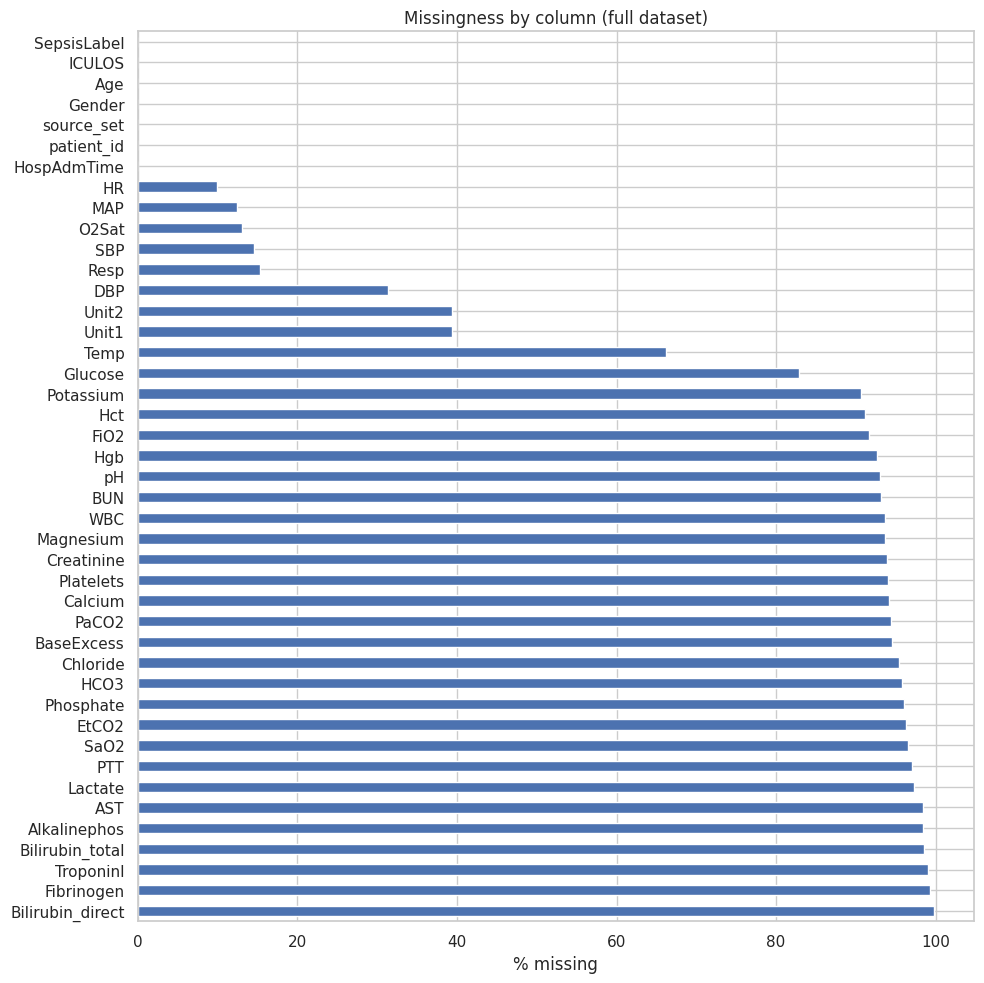

In [27]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct.round(2),
})
display(missing_report)

plt.figure(figsize=(10, 10))
missing_pct.plot(kind="barh")
plt.xlabel("% missing")
plt.title("Missingness by column (full dataset)")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "01_missingness_by_column.png", dpi=150)
plt.show()


## 5. Unique values & duplicate records

In [28]:
unique_counts = df.nunique().sort_values(ascending=False)
display(unique_counts.to_frame("n_unique"))

n_duplicate_rows = df.duplicated().sum()
print(f"Fully duplicated rows: {n_duplicate_rows}")


,n_unique
patient_id,40336
HospAdmTime,12156
Age,5987
TroponinI,2423
AST,2025
PTT,1410
Creatinine,1407
Lactate,1340
Glucose,1157
SBP,990


Fully duplicated rows: 0


## 6. Target analysis: `SepsisLabel`

Observation-level SepsisLabel counts:


,count,pct
SepsisLabel,,
0.0,1524294,98.202
1.0,27916,1.798


Sepsis-positive patients : 2932
Sepsis-negative patients : 37404
Patient-level prevalence : 7.269%
Sepsis-positive observations : 27916
Sepsis-negative observations : 1524294


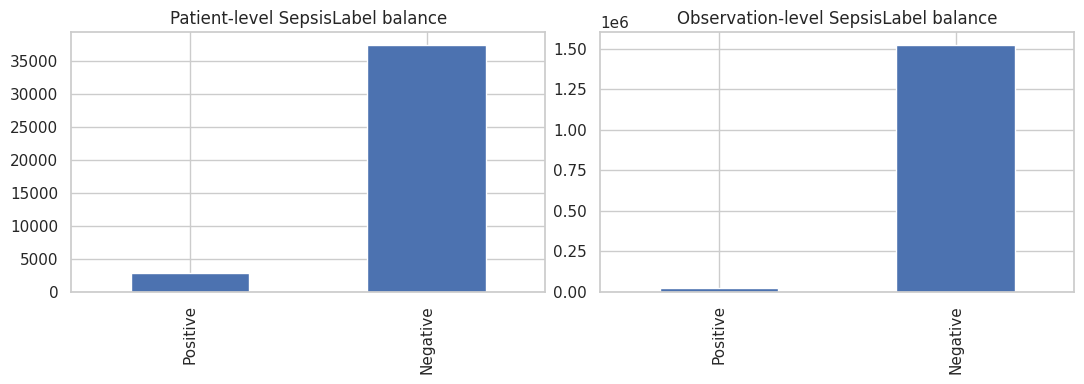

In [29]:
# Observation-level (hour-level) prevalence
obs_counts = df[config.TARGET_COL].value_counts(dropna=False)
obs_pct = df[config.TARGET_COL].value_counts(normalize=True, dropna=False) * 100
print("Observation-level SepsisLabel counts:")
display(pd.DataFrame({"count": obs_counts, "pct": obs_pct.round(3)}))

# Patient-level prevalence: a patient is "sepsis-positive" if SepsisLabel == 1 at any hour
patient_label = df.groupby(config.PATIENT_ID_COL)[config.TARGET_COL].max()
n_pos_patients = int((patient_label == 1).sum())
n_neg_patients = int((patient_label == 0).sum())

print(f"Sepsis-positive patients : {n_pos_patients}")
print(f"Sepsis-negative patients : {n_neg_patients}")
print(f"Patient-level prevalence : {n_pos_patients / (n_pos_patients + n_neg_patients):.3%}")

n_pos_obs = int((df[config.TARGET_COL] == 1).sum())
n_neg_obs = int((df[config.TARGET_COL] == 0).sum())
print(f"Sepsis-positive observations : {n_pos_obs}")
print(f"Sepsis-negative observations : {n_neg_obs}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pd.Series({"Positive": n_pos_patients, "Negative": n_neg_patients}).plot(kind="bar", ax=axes[0])
axes[0].set_title("Patient-level SepsisLabel balance")
pd.Series({"Positive": n_pos_obs, "Negative": n_neg_obs}).plot(kind="bar", ax=axes[1])
axes[1].set_title("Observation-level SepsisLabel balance")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "01_target_balance.png", dpi=150)
plt.show()


## 7. ICU length-of-stay (ICULOS) statistics

Minimum ICU length (hours) : 8
Maximum ICU length (hours) : 336
Median ICU length (hours)  : 39.0
Mean ICU length (hours)    : 39.0


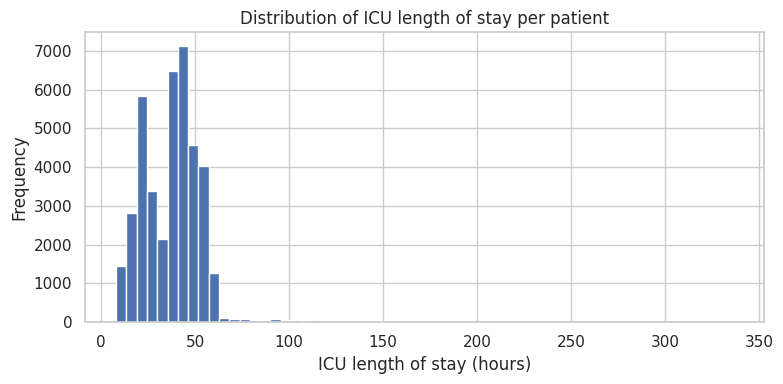

In [30]:
icu_hours_per_patient = df.groupby(config.PATIENT_ID_COL)["ICULOS"].max()

print(f"Minimum ICU length (hours) : {icu_hours_per_patient.min():.0f}")
print(f"Maximum ICU length (hours) : {icu_hours_per_patient.max():.0f}")
print(f"Median ICU length (hours)  : {icu_hours_per_patient.median():.1f}")
print(f"Mean ICU length (hours)    : {icu_hours_per_patient.mean():.1f}")

plt.figure(figsize=(8, 4))
icu_hours_per_patient.plot(kind="hist", bins=60)
plt.xlabel("ICU length of stay (hours)")
plt.title("Distribution of ICU length of stay per patient")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "01_icu_los_distribution.png", dpi=150)
plt.show()


## 8. Save the data-understanding summary table

This table becomes the factual basis for the README "Dataset" section and the final report —
no number there should ever be typed in by hand separately from this output.


In [31]:
summary = {
    "n_patient_files": len(files),
    "n_unique_patients": int(n_patients),
    "total_observations": int(n_obs),
    "n_columns": int(n_cols),
    "n_duplicate_rows": int(n_duplicate_rows),
    "sepsis_positive_patients": n_pos_patients,
    "sepsis_negative_patients": n_neg_patients,
    "patient_level_prevalence_pct": round(100 * n_pos_patients / (n_pos_patients + n_neg_patients), 3),
    "sepsis_positive_observations": n_pos_obs,
    "sepsis_negative_observations": n_neg_obs,
    "icu_los_min_hours": float(icu_hours_per_patient.min()),
    "icu_los_max_hours": float(icu_hours_per_patient.max()),
    "icu_los_median_hours": float(icu_hours_per_patient.median()),
}
summary_df = pd.DataFrame([summary])
display(summary_df)

summary_df.to_csv(config.TABLES_DIR / "01_data_understanding_summary.csv", index=False)
print("Saved to", config.TABLES_DIR / "01_data_understanding_summary.csv")


,n_patient_files,n_unique_patients,total_observations,n_columns,n_duplicate_rows,sepsis_positive_patients,sepsis_negative_patients,patient_level_prevalence_pct,sepsis_positive_observations,sepsis_negative_observations,icu_los_min_hours,icu_los_max_hours,icu_los_median_hours
0,40336,40336,1552210,43,0,2932,37404,7.269,27916,1524294,8.0,336.0,39.0


Saved to /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/01_data_understanding_summary.csv


---
### What to send back to Claude after running this notebook

Please paste (or upload the CSV of) the output of the **Section 8 summary table**, plus:
- The printed shape and column list from Section 3
- The missingness table from Section 4
- Any errors/warnings printed (especially from `discover_patient_files` or ICULOS monotonicity checks)

With that, Phase 2 (Data Understanding) can be written up with real numbers, and we can move
correctly into Phase 3 (Data Cleaning) using the actual missingness/quality patterns found.


In [18]:
!mkdir -p /content/local_data/raw/training_setA /content/local_data/raw/training_setB
!rsync -a --info=progress2 /content/drive/MyDrive/sepsis_data/raw/training_setA/ /content/local_data/raw/training_setA/
!rsync -a --info=progress2 /content/drive/MyDrive/sepsis_data/raw/training_setB/ /content/local_data/raw/training_setB/

    131,388,704 100%  196.03kB/s    0:10:54 (xfr#20336, to-chk=0/20337)
    123,668,780 100%  192.42kB/s    0:10:27 (xfr#20000, to-chk=0/20001)


In [19]:
!ls /content/local_data/raw/training_setA | wc -l
!ls /content/local_data/raw/training_setB | wc -l

20336
20000


In [32]:
%cd "/content/drive/MyDrive/Early-Sepsis-Detection"
!ls src/
!ls notebooks/

/content/drive/MyDrive/Early-Sepsis-Detection
config.py  data_cleaning.py  data_loader.py  __init__.py  __pycache__
01_data_understanding.ipynb  02_data_cleaning.ipynb
